# SIR Simulator: Conjugate Method (Case 1) Notebook

This notebook demonstrates how to run the conjugate posterior estimation (Case 1) for the SIR simulator.

It covers:
1. Setting up the SIR simulator.
2. Generating training data and training the `q_phi` neural networks.
3. Generating observed data with outliers.
4. Calibrating $\beta$ using the GPC method.
5. Computing the conjugate posterior mean and covariance.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import MultivariateNormal
#from pathlib import Path
#import pickle

from nsm_bayes.simulators import simulate_sir, sir_summary
from nsm_bayes.conj import TphiNet, BphiNet, train_q_phi
from nsm_bayes.method import (
    compute_posterior_case1,
    robust_mean_cov,
    w_imq_squared,
)
from nsm_bayes.gpc import calibrate_beta_gpc

## 1. Configuration

Set some values for the parameters. The SIR simulator has four different parameters. 

In [2]:
cfg = {
    "prior_mean": [0.5, 0.2, 0.5, 20],
    "prior_std": [0.5, 0.5, 1.0, 0.7],
    "theta_true": [0.6, 0.15, 0.6, 20.0],
    "N_sir": 1000,
    "T_sir": 150,
    "num_samples": 5000,
    "d_x": 3,
    "hidden_dim": 128,
    "beta_base_case1": 0.01,
    "beta_min_case1": 1e-4,
    "alpha": 0.05,
    "T": 20,
    "B": 100,
    "epsilon": 0.05,
    "n_obs": 100
}

dtype = torch.float32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

prior_mean = torch.tensor([
    torch.log(torch.tensor(cfg["prior_mean"][0])),
    torch.log(torch.tensor(cfg["prior_mean"][1])),
    torch.logit(torch.tensor(cfg["prior_mean"][2])),
    torch.log(torch.tensor(cfg["prior_mean"][3])),
], dtype=dtype, device=device)

prior_std = torch.tensor(cfg["prior_std"], dtype=dtype, device=device)
prior_cov = torch.diag(prior_std ** 2)

theta_true = torch.tensor([
    torch.log(torch.tensor(cfg["theta_true"][0])),
    torch.log(torch.tensor(cfg["theta_true"][1])),
    torch.logit(torch.tensor(cfg["theta_true"][2])),
    torch.log(torch.tensor(cfg["theta_true"][3]))
], dtype=dtype, device=device)

print(f"Device: {device}")
print(f"Prior Mean: {prior_mean}")
print(f"True Theta: {theta_true}")

Device: cpu
Prior Mean: tensor([-0.6931, -1.6094,  0.0000,  2.9957])
True Theta: tensor([-0.5108, -1.8971,  0.4055,  2.9957])


## 2. Training the `q_phi` Networks

Next, we generate data from the prior, and use these to simulate from the prior and use the pairs $(\theta_i,x_i)$ to train neural networks $T$ and $B$. This gives a surrogate model for the density, where we assume the functional form
\begin{equation*}
\exp\{-T(\theta)x - B(\theta)\}
\end{equation*}

Simulating training data...
Training q_phi networks...
Starting training for q_phi...


/u/08/sohkanj1/unix/Documents/projects/nsm-bayes/myenv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Epoch [1/100] | Train Loss: -0.655877 | Val Loss: -2.024353
Epoch [10/100] | Train Loss: -569.321445 | Val Loss: -613.299680
Epoch [20/100] | Train Loss: -1972.893746 | Val Loss: -1991.400261
Epoch [30/100] | Train Loss: -3647.623553 | Val Loss: -3622.118996
Epoch [40/100] | Train Loss: -5357.513711 | Val Loss: -5273.859016
Epoch [50/100] | Train Loss: -7116.247305 | Val Loss: -6929.111473
Epoch [60/100] | Train Loss: -8912.003855 | Val Loss: -8582.534988
Epoch [70/100] | Train Loss: -10766.657938 | Val Loss: -10291.011780
Epoch [80/100] | Train Loss: -12711.993711 | Val Loss: -12090.186356
Epoch [90/100] | Train Loss: -14781.016086 | Val Loss: -13979.862091
Epoch [100/100] | Train Loss: -16959.658023 | Val Loss: -16051.096924
Training finished. Loading best model from epoch 100 with validation loss -16051.096924.


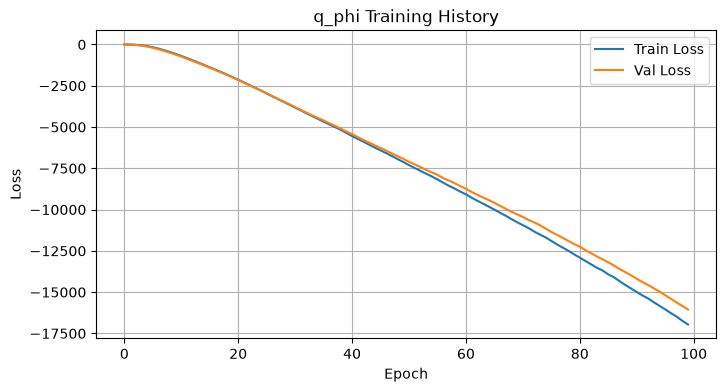

In [3]:
prior = MultivariateNormal(loc=prior_mean, covariance_matrix=prior_cov)
theta = prior.sample((cfg["num_samples"],)).to(device)

print("Simulating training data...")
y_sim = simulate_sir(theta, T=cfg["T_sir"], N=cfg["N_sir"])
x_sim = sir_summary(y_sim, cfg["N_sir"])

# Initialize networks
T_phi_net = TphiNet(cfg["d_x"], cfg["hidden_dim"], 4).to(device)
b_phi_net = BphiNet(cfg["d_x"], cfg["hidden_dim"]).to(device)

print("Training q_phi networks...")
history = train_q_phi(x_sim, theta, T_phi_net, b_phi_net)

plt.figure(figsize=(8, 4))
plt.plot(history['train_losses'], label='Train Loss')
plt.plot(history['val_losses'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('q_phi Training History')
plt.legend()
plt.grid(True)
plt.show()

## 3. Generating Observed Data

The surrogate density model is trained on clean data. We assume that this surrogate is a good match for the simulator.

We then want to use the model to perform inference on our true data, which may contain outliers. To demonstrate the inference, let's generate some more "observed" data from the toy simulator, and then artificially introduce some outliers.

The actual surrogate model is not retrained.

In [5]:
n_obs = cfg["n_obs"]
theta_obs = theta_true.repeat(n_obs, 1)
y_obs = simulate_sir(theta_obs, T=cfg["T_sir"], N=cfg["N_sir"])
x_obs = sir_summary(y_obs, cfg["N_sir"])

# Introduce outliers
epsilon = cfg["epsilon"]
n_outliers = int(epsilon * n_obs)
outlier_indices = np.random.choice(n_obs, n_outliers, replace=False)

x_obs_mis = x_obs.clone()
if n_outliers > 0:
    # Replace outliers with random noise from the simulation range
    noise = torch.randn(n_outliers, cfg["d_x"], device=device) * 2.0
    x_obs_mis[outlier_indices] = noise

print(f"Generated {n_obs} observations with {n_outliers} outliers.")

Generated 100 observations with 5 outliers.


## 4. Inference on real data
To use the model for inference, we first normalize the data. 

We then calibrate $\beta$. Since the score-matching loss used here is not a log-likelihood, we need to use $\beta$ to ensure that it is on the 

and compute the posterior.

In [6]:
from sklearn.preprocessing import StandardScaler

# Standardize using simulation data
scaler_x = StandardScaler().fit(x_sim.cpu().numpy())
scaler_theta = StandardScaler().fit(theta.cpu().numpy())

class TorchStandardizer(torch.nn.Module):
    def __init__(self, scaler):
        super().__init__()
        self.mean = torch.tensor(scaler.mean_, dtype=torch.float32)
        self.std = torch.tensor(scaler.scale_, dtype=torch.float32)
    def forward(self, x):
        return (x - self.mean.to(x.device)) / self.std.to(x.device)
    def inverse(self, x):
        return x * self.std.to(x.device) + self.mean.to(x.device)

standardizer_x = TorchStandardizer(scaler_x).to(device)
standardizer_theta = TorchStandardizer(scaler_theta).to(device)

x_obs_normalized = standardizer_x(x_obs_mis)
prior_mean_normalized = standardizer_theta(prior_mean)
scales = standardizer_theta.std
prior_cov_normalized = prior_cov / torch.outer(scales, scales)

# Robust mean and covariance
mu_hat_obs, Sigma_hat_obs = robust_mean_cov(x_obs_normalized)
Sigma_inv_obs = torch.linalg.inv(Sigma_hat_obs + 1e-6 * torch.eye(cfg["d_x"], device=device))
c_case1 = 1.0

print("Calibrating beta using GPC...")
calibrated_beta, gpc_history = calibrate_beta_gpc(
    x_obs=x_obs_mis,
    T_phi_net=T_phi_net,
    b_phi_net=b_phi_net,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
    standardizer_x=standardizer_x,
    standardizer_theta=standardizer_theta,
    initial_beta=cfg["beta_base_case1"],
    target_coverage=1.0 - cfg["alpha"],
    num_iterations=cfg["T"],
    num_bootstraps=cfg["B"],
    learning_rate_fn=lambda t: 10.0 / (t + 10.),
    beta_min=cfg["beta_min_case1"]
)

print(f"Calibrated Beta: {calibrated_beta:.6f}")

# Compute posterior
mu_n_normalized, Sigma_n_normalized = compute_posterior_case1(
    x_obs_normalized, T_phi_net, b_phi_net, calibrated_beta, 
    prior_mean_normalized, prior_cov_normalized, w_imq_squared, 
    mu_hat_obs, Sigma_inv_obs, c_case1
)

# Transform back to original scale
mu_n = standardizer_theta.inverse(mu_n_normalized)
Sigma_n = Sigma_n_normalized * torch.outer(scales, scales)

print("\nPosterior Mean:")
print(mu_n)
print("\nTrue Theta:")
print(theta_true)

Calibrating beta using GPC...
--- Starting General Posterior Calibration for beta ---
A:  tensor([[ 226448.6250,  122147.2734,   66286.4688, -168633.5938],
        [ 122147.2734,   86720.7266,   34704.4766, -112301.2812],
        [  66286.4688,   34704.4766,   20221.1895,  -47651.4609],
        [-168633.5938, -112301.2812,  -47651.4609,  151678.3281]],
       grad_fn=<SumBackward1>)
A eig min/max: 570.196533203125 457450.59375
cond(A): 802.268310546875
||B||: 182414.046875
Estimated true theta:  tensor([-0.6227, -1.4276,  0.7340,  3.0218])


Iter 1/20 | beta=0.0100: 100%|██████████| 100/100 [00:04<00:00, 21.40it/s]


Iter 1/20 | Current Beta: 0.0078 | Empirical Coverage: 0.120 | Target: 0.95


Iter 2/20 | beta=0.0078: 100%|██████████| 100/100 [00:03<00:00, 28.15it/s]


Iter 2/20 | Current Beta: 0.0061 | Empirical Coverage: 0.240 | Target: 0.95


...

Iter 18/20 | Current Beta: 0.0039 | Empirical Coverage: 0.990 | Target: 0.95


Iter 19/20 | beta=0.0039: 100%|██████████| 100/100 [00:03<00:00, 25.13it/s]


Iter 19/20 | Current Beta: 0.0039 | Empirical Coverage: 0.930 | Target: 0.95


Iter 20/20 | beta=0.0039: 100%|██████████| 100/100 [00:04<00:00, 23.61it/s]


Iter 20/20 | Current Beta: 0.0039 | Empirical Coverage: 0.950 | Target: 0.95
Final calibrated beta: 0.0039
Calibrated Beta: 0.003891

Posterior Mean:
tensor([-0.7595, -1.4061,  1.5665,  3.0147], grad_fn=<AddBackward0>)

True Theta:
tensor([-0.5108, -1.8971,  0.4055,  2.9957])


## 5. Results Visualization

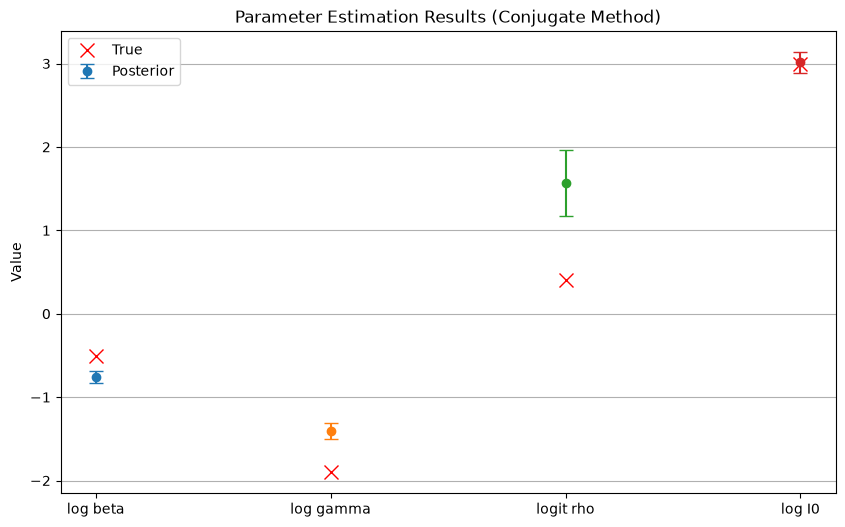

In [8]:
labels = ["log beta", "log gamma", "logit rho", "log I0"]
mu_n_np = mu_n.detach().cpu().numpy()
theta_true_np = theta_true.detach().cpu().numpy()
std_n_np = torch.sqrt(torch.diag(Sigma_n)).detach().cpu().numpy()

plt.figure(figsize=(10, 6))
for i in range(4):
    plt.errorbar(i, mu_n_np[i], yerr=std_n_np[i], fmt='o', capsize=5, label='Posterior' if i==0 else "")
    plt.plot(i, theta_true_np[i], 'rx', markersize=10, label='True' if i==0 else "")

plt.xticks(range(4), labels)
plt.ylabel("Value")
plt.title("Parameter Estimation Results (Conjugate Method)")
plt.legend()
plt.grid(True, axis='y')
plt.show()